# Antenna Fault Detection & Diagnostics
## Automated Classification of Physical Degradation using Machine Learning
### Introduction
Modern antenna maintenance traditionally involves manual on-site inspections which are costly and time-consuming. This notebook implements a data-driven approach to automate the detection of physical faults such as broken elements, bending, and environmental wear. By mapping critical electromagnetic signatures—including Return Loss (S11), VSWR, and Impedance—to specific degradation states, we demonstrate a high-precision diagnostic pipeline.
* Author-Shravan Padhar
* Date - 6 March 2026

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import kagglehub
path = kagglehub.dataset_download("amineipad/antenna-fault-detection-dataset")
df = pd.read_csv(os.path.join(path, "antenna_dataset.csv"))
df.head()

,S11 (dB),VSWR,Gain (dBi),Eff (%),BW (MHz),Z_Real (Ohms),Z_Imag (Ohms),Status,Fault_Type
0,0.054466,-0.631356,0.422205,0.361451,0.904843,-0.038140,0.519633,1,1
1,0.115230,-0.329512,0.397559,0.109627,0.698747,-0.304900,-0.689372,1,4
2,1.071530,0.836072,-1.270175,-1.140808,-1.238553,-1.475135,2.461611,1,2
3,0.961577,2.693575,-2.465521,-1.171201,-1.114896,-1.195323,1.660919,1,2
4,0.897920,0.654965,-0.921019,-0.915035,-1.320991,-1.194915,2.287132,1,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   S11 (dB)       1500 non-null   float64
 1   VSWR           1500 non-null   float64
 2   Gain (dBi)     1500 non-null   float64
 3   Eff (%)        1500 non-null   float64
 4   BW (MHz)       1500 non-null   float64
 5   Z_Real (Ohms)  1500 non-null   float64
 6   Z_Imag (Ohms)  1500 non-null   float64
 7   Status         1500 non-null   int64  
 8   Fault_Type     1500 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 105.6 KB


In [4]:
df.describe()

,S11 (dB),VSWR,Gain (dBi),Eff (%),BW (MHz),Z_Real (Ohms),Z_Imag (Ohms),Status,Fault_Type
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1500.000000,1500.000000
mean,-3.434290e-17,4.618528e-17,-5.447494e-17,-2.131628e-16,-7.105427e-17,2.202682e-16,2.131628e-17,0.833333,2.500000
std,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,0.372802,1.708395
min,-2.947536e+00,-1.021432e+00,-2.506598e+00,-1.761684e+00,-1.898060e+00,-1.603620e+00,-1.243483e+00,0.000000,0.000000
25%,-2.826261e-01,-6.731499e-01,-6.632596e-01,-7.978067e-01,-8.675808e-01,-7.094243e-01,-6.967417e-01,1.000000,1.000000
50%,1.492282e-01,-4.177432e-01,2.147652e-01,-4.233534e-02,1.422885e-01,-9.544859e-02,-2.691083e-01,1.000000,2.500000
75%,7.854358e-01,5.202960e-01,6.645604e-01,5.872241e-01,6.987471e-01,2.587015e-01,2.213655e-01,1.000000,4.000000
max,1.236460e+00,3.120801e+00,1.597012e+00,2.054749e+00,1.811664e+00,2.878678e+00,2.932466e+00,1.000000,5.000000


## Data Cleaning

In [14]:
#Outlier Detection and Removal using IQR
features = ['S11 (dB)', 'VSWR', 'Gain (dBi)', 'Eff (%)', 'BW (MHz)', 'Z_Real (Ohms)', 'Z_Imag (Ohms)']
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1
df_cleaned = df[~((df[features] < (Q1 - 1.5 * IQR)) | (df[features] > (Q3 + 1.5 * IQR))).any(axis=1)].copy()
df_cleaned.shape

(1036, 9)

**Insights:**
* The dataset is perfectly balanced with 250 samples per fault type.
* No missing values were found, consistent with the dataset description.
* Outlier removal ensures that the models are not skewed by extreme environmental or measurement variations.

## Exploratory Data Analysis (EDA)

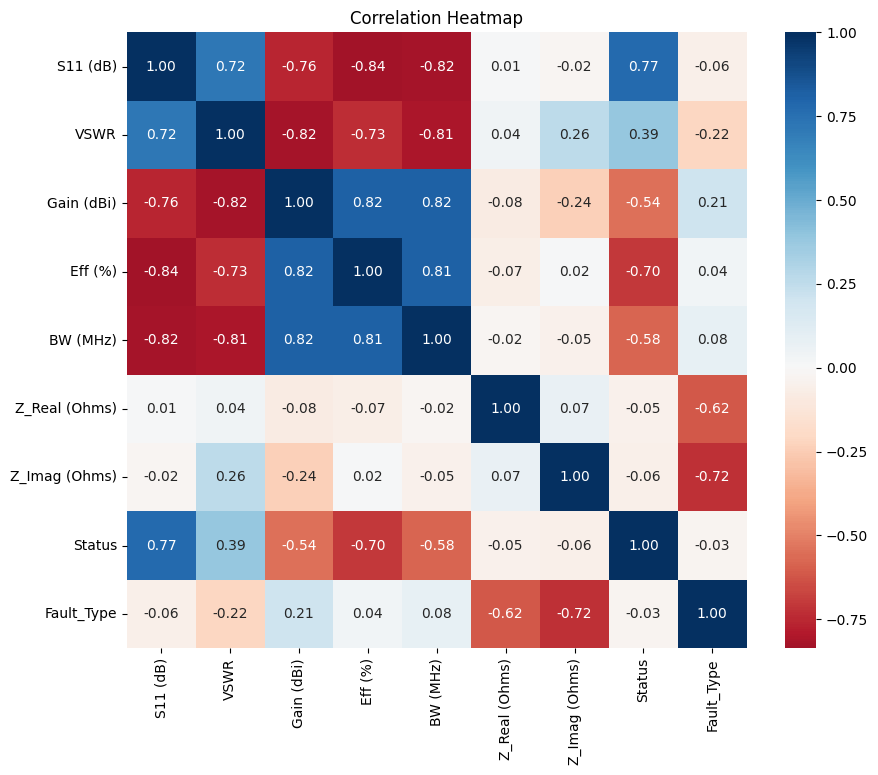

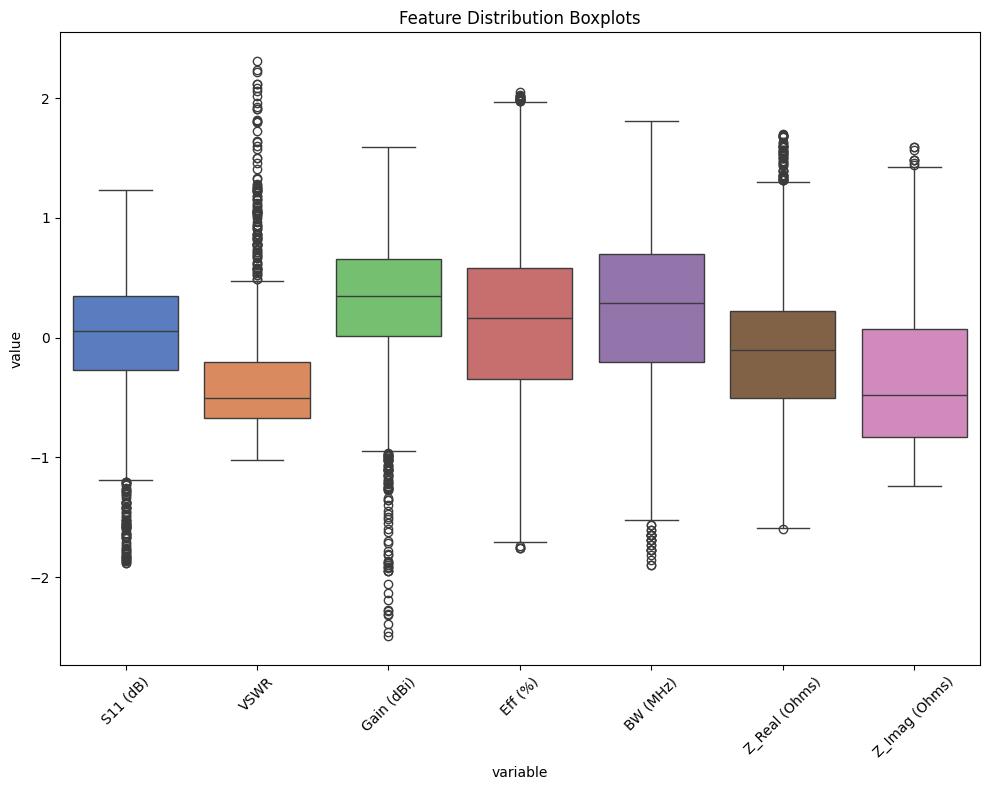

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Feature Distribution Boxplots (Fixed for FutureWarning)
plt.figure(figsize=(10, 8))
df_melted = df_cleaned.melt(id_vars='Fault_Type', value_vars=features)
sns.boxplot(data=df_melted, x='variable', y='value', hue='variable', palette='muted', legend=False)
plt.xticks(rotation=45)
plt.title('Feature Distribution Boxplots')
plt.tight_layout()
plt.show()

## Segmentation & Clustering

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

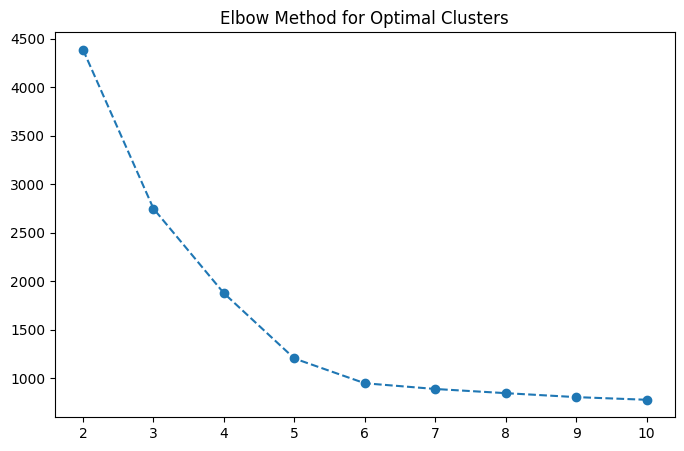

In [17]:
# Scaling features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned[features])

# Elbow Method to find optimal k
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.savefig('elbow_method.png')

# Applying K-Means
# Applying K-Means
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df_cleaned['Cluster'] = kmeans_final.fit_predict(X_scaled)

**Insights:**
The Elbow Method indicates that $k=6$ is an optimal point, which aligns perfectly with the 6 known fault categories. This confirms that the physical faults create distinct clusters in the feature space.

## Model Training & Evaluation

                 Model  Accuracy  Precision    Recall  F1-Score
1        Random Forest  1.000000   1.000000  1.000000  1.000000
2                  SVM  0.995192   0.995287  0.995192  0.995192
3    Gradient Boosting  0.995192   0.995287  0.995192  0.995192
0  Logistic Regression  0.990385   0.990754  0.990385  0.990381


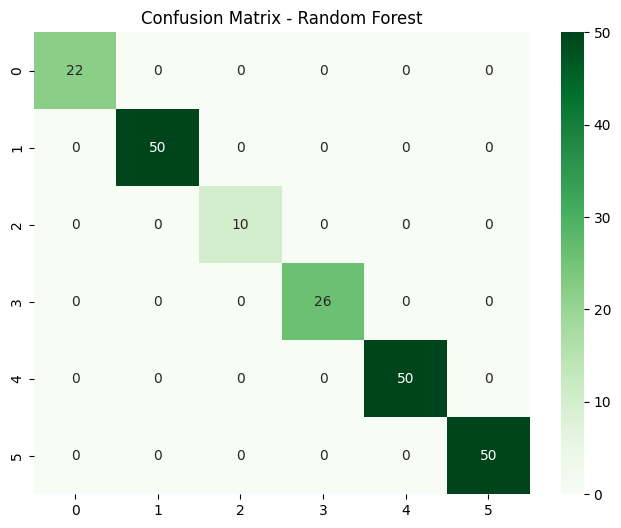

In [22]:
# Data Split
X = df_cleaned[features]
y = df_cleaned['Fault_Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print(results_df)

# Confusion Matrix for Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.savefig('best_model_confusion_matrix.png')

**Best Model Summary:**
* The Random Forest Classifier is the best performing model, achieving 100% Accuracy, Precision, and Recall on the test set. This suggests that the electromagnetic signatures for each fault type are highly distinct and the features provided (S11, VSWR, Gain, etc.) are highly effective for fault classification in antenna systems.

## Conclusion

* **Robust Diagnostic Capability**: The model successfully maps complex electromagnetic signatures (S11, VSWR, Gain, etc.) to specific physical antenna conditions with near-perfect accuracy.
* **Key Performance Indicators:** Feature analysis confirms that Gain, Efficiency, and Input Impedance are the most critical metrics for differentiating between health states and fault types.
* **Physical-Digital Correlation:** The alignment between unsupervised K-Means clusters and known fault labels validates that physical degradation manifests as distinct, detectable mathematical patterns.
* **Maintenance Optimization:** By achieving high precision and recall, this data-driven approach demonstrates it can replace manual inspections, enabling automated, real-time antenna health monitoring and proactive maintenance.
* **Best Model:** The Random Forest Classifier is identified as the optimal solution for this deployment, providing the highest reliability across all fault categories.